# Setup

In [1]:
import importlib, sys
sys.path.insert(0, '/workspace/GRB_Analysis')

import grb_utils as gu
importlib.reload(gu)
from grb_utils import *

import grb_config
importlib.reload(grb_config)
from grb_config import grbs_df

KeyboardInterrupt: 

In [ ]:
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib.colors import Normalize
import json
import pandas as pd
from tqdm.auto import tqdm
import h5py
import arviz as az
import matplotlib.cm as cm
import json

# from heapy.util.data import msg_format
from heapy.util.time import fermi_utc_to_met
from heapy.data.retrieve import gbmRetrieve
from heapy.geos.geometry import gbmGeometry
from heapy.pipe.event import gbmTTE
from bayspec.model.local import *
from bayspec import DataUnit, Data, BayesInfer, Plot, MaxLikeFit

In [ ]:
grbs_df

,name,ra,dec,utc,sel_dets,time_slices
0,GRB131011A,32.526,-4.411,2013-10-11T17:47:34.99,"[b1, n9, na, nb]","[(-2.99, 1.74), (1.74, 3.56), (3.56, 5.066), (..."


# Query Fermi GBM Data

In [ ]:
for _, grb in grbs_df.iterrows():
    load_grb(grb)
    print(f"#-----------------------x| for {GRB_Name} |x------------------------#")
    # Base paths
    base = f'{GRB_Name}'
    gbm_data = 'gbm_data'
    # Time-integrated analysis
    tintegrated_path = f'{GRB_Name}/data/tintegrated'
    heapy_tintegrated_path = f'{GRB_Name}/data/tintegrated/heapy'
    bayspec_tintegrated_path = f'{GRB_Name}/data/tintegrated/bayspec'

    # Time-resolved analysis
    tresolved_path = f'{GRB_Name}/data/tresolved'
    heapy_tresolved_path = f'{GRB_Name}/data/tresolved/heapy'
    bayspec_tresolved_path = f'{GRB_Name}/data/tresolved/bayspec'

    bayspec_data = f'{bayspec_tresolved_path}/{GRB_Name}_bayspec_data.h5'

    # Sampler output
    Sampler_Output_DIR = f'{GRB_Name}/data/Sampler_Output'
    Posterior_Stat_File = os.path.join(Sampler_Output_DIR,f'{GRB_Name}_posterior_stat.h5')

    # Create directories
    os.makedirs(gbm_data, exist_ok=True)
    os.makedirs(tintegrated_path, exist_ok=True)
    os.makedirs(tresolved_path, exist_ok=True)
    os.makedirs(heapy_tintegrated_path, exist_ok=True)
    os.makedirs(bayspec_tintegrated_path, exist_ok=True)
    os.makedirs(heapy_tresolved_path, exist_ok=True)
    os.makedirs(bayspec_tresolved_path, exist_ok=True)
    os.makedirs(Sampler_Output_DIR, exist_ok=True)

    print(" Downloading Data ----> ")
    fermi_met = fermi_utc_to_met(utc)
    gbm_rtv = gbmRetrieve.from_utc(utc=utc, t1=-400, t2=400, datapath=gbm_data)
    
    gbm_rtv.rtv_res
    print(" Data Downloaded Successfully !")

    dets = ['n0','n1','n2','n3','n4','n5','n6','n7','n8','n9','na','nb','b0','b1']

    gbm_geo = gbmGeometry(file=gbm_rtv.rtv_res['poshist'])
    # print("gbm_geo.saa_passage : ",gbm_geo.saa_passage(met=[fermi_met-500, fermi_met, fermi_met+500]))
    print("gbm_geo.saa_passage : ", gbm_geo.saa_passage)
    print("gbm_geo.location_visible :", gbm_geo.get_location_visible(ra=RA, dec=DEC, met=[fermi_met-500, fermi_met, fermi_met+500]))

    for det in dets:
        angle = gbm_geo.get_detector_angle(ra=RA, dec=DEC, det=det, 
                                    met=[fermi_met-100, fermi_met, fermi_met+100])
        # print(det, angle)

    gbm_geo.extract_skymap(ra=RA, dec=DEC, met=fermi_met, savepath=f'{GRB_Name}/geometry')

    print(f"#-----------------------x| The End |x------------------------#")

Loaded: GRB131011A | RA=32.526 | DEC=-4.411 | None slices | tint_window=(None,None) | dets=['b1', 'n9', 'na', 'nb']
#-----------------------x| for GRB131011A |x------------------------#
 Data Downloaded Successfully !
gbm_geo.saa_passage :  [ True  True  True ...  True  True  True]
gbm_geo.location_visible : [ True  True  True]
#-----------------------x| The End |x------------------------#


In [ ]:
# ---- Stage 1: download data + geometry (once per GRB) ----
for _, grb in grbs_df.iterrows():
    load_grb(grb)
    print(f"#---x| {GRB_Name} |x---#")
    extract_geometry()

Loaded: GRB131011A | RA=32.526 | DEC=-4.411 | 6 slices | tint_window=(None,None) | dets=['b1', 'n9', 'na', 'nb']
#---x| GRB131011A |x---#
saa_passage: [ True  True  True ...  True  True  True]
location_visible: [ True  True  True]
n0 [83.69877933 85.42286615 87.50554523]
n1 [ 98.1530276   99.9229862  101.98690569]
n2 [107.15629247 108.23081793 109.31481755]
n3 [111.53885081 112.53721586 113.8667652 ]
n4 [134.16334882 133.68546901 133.25705876]
n5 [155.72488162 157.45372449 159.42386162]
n6 [63.00008651 64.11407697 65.60640976]
n7 [55.29050845 55.60788763 56.23114837]
n8 [71.16258867 70.0692808  68.96285136]
n9 [37.61294636 39.38499799 41.45653488]
na [45.59911206 46.04091642 46.42688943]
nb [24.62113004 22.89616576 20.93308099]
b0 [158.03340684 159.7983263  161.84300366]
b1 [21.96659316 20.2016737  18.15699634]


# Extract LightCurves and Spectra using Heapy

In [37]:

# ---- Stage 2: time-integrated lightcurve + spectrum ----
for _, grb in grbs_df.iterrows():
    load_grb(grb)
    extract_tintegrated_spectra()
 

Loaded: GRB131011A | RA=32.526 | DEC=-4.411 | 6 slices | tint_window=(None,None) | dets=['b1', 'n9', 'na', 'nb']

b1


findfont: Generic family 'serif' not found because none of the following families were found: STIX Two Text
findfont: Generic family 'serif' not found because none of the following families were found: STIX Two Text
findfont: Generic family 'serif' not found because none of the following families were found: STIX Two Text
findfont: Generic family 'serif' not found because none of the following families were found: STIX Two Text
findfont: Generic family 'serif' not found because none of the following families were found: STIX Two Text
findfont: Generic family 'serif' not found because none of the following families were found: STIX Two Text
findfont: Generic family 'serif' not found because none of the following families were found: STIX Two Text
findfont: Generic family 'serif' not found because none of the following families were found: STIX Two Text
findfont: Generic family 'serif' not found because none of the following families were found: STIX Two Text
findfont: Generic family 'se

findfont: Generic family 'serif' not found because none of the following families were found: STIX Two Text
findfont: Generic family 'serif' not found because none of the following families were found: STIX Two Text
findfont: Generic family 'serif' not found because none of the following families were found: STIX Two Text
findfont: Generic family 'serif' not found because none of the following families were found: STIX Two Text
findfont: Generic family 'serif' not found because none of the following families were found: STIX Two Text
findfont: Generic family 'serif' not found because none of the following families were found: STIX Two Text
findfont: Generic family 'serif' not found because none of the following families were found: STIX Two Text
findfont: Generic family 'serif' not found because none of the following families were found: STIX Two Text
findfont: Generic family 'serif' not found because none of the following families were found: STIX Two Text
findfont: Generic family 'se


+----------------------------------------------+
| id#  T90       T90-    T90+    T901    T902  |
+----------------------------------------------+
| 1    21.500    14.500  22.000  -14.250 7.250 |
+----------------------------------------------+



n9


...

findfont: Generic family 'serif' not found because none of the following families were found: STIX Two Text
findfont: Generic family 'serif' not found because none of the following families were found: STIX Two Text
findfont: Generic family 'serif' not found because none of the following families were found: STIX Two Text
findfont: Generic family 'serif' not found because none of the following families were found: STIX Two Text
findfont: Generic family 'serif' not found because none of the following families were found: STIX Two Text
findfont: Generic family 'serif' not found because none of the following families were found: STIX Two Text
findfont: Generic family 'serif' not found because none of the following families were found: STIX Two Text
findfont: Generic family 'serif' not found because none of the following families were found: STIX Two Text
findfont: Generic family 'serif' not found because none of the following families were found: STIX Two Text
findfont: Generic family 'se

findfont: Generic family 'serif' not found because none of the following families were found: STIX Two Text
findfont: Generic family 'serif' not found because none of the following families were found: STIX Two Text
findfont: Generic family 'serif' not found because none of the following families were found: STIX Two Text
findfont: Generic family 'serif' not found because none of the following families were found: STIX Two Text
findfont: Generic family 'serif' not found because none of the following families were found: STIX Two Text
findfont: Generic family 'serif' not found because none of the following families were found: STIX Two Text
findfont: Generic family 'serif' not found because none of the following families were found: STIX Two Text
findfont: Generic family 'serif' not found because none of the following families were found: STIX Two Text
findfont: Generic family 'serif' not found because none of the following families were found: STIX Two Text
findfont: Generic family 'se


+-----------------------------------------------+
| id#  T90       T90-    T90+    T901    T902   |
+-----------------------------------------------+
| 1    73.487    15.737  8.498   -3.285  70.201 |
+-----------------------------------------------+


findfont: Generic family 'serif' not found because none of the following families were found: STIX Two Text
findfont: Generic family 'serif' not found because none of the following families were found: STIX Two Text
findfont: Generic family 'serif' not found because none of the following families were found: STIX Two Text
findfont: Generic family 'serif' not found because none of the following families were found: STIX Two Text
findfont: Generic family 'serif' not found because none of the following families were found: STIX Two Text
findfont: Generic family 'serif' not found because none of the following families were found: STIX Two Text
findfont: Generic family 'serif' not found because none of the following families were found: STIX Two Text
findfont: Generic family 'serif' not found because none of the following families were found: STIX Two Text
findfont: Generic family 'serif' not found because none of the following families were found: STIX Two Text
findfont: Generic family 'se

/usr/local/lib/python3.12/site-packages/responsum/response.py:108: RuntimeWarning: Minimum MC energy (5.0) is larger than minimum EBOUNDS energy (4.323753833770752)
  warnings.warn(


# Fit Spectrum to Basic Models like Band, Cutoff Powerlaw etc. using Bayspec

Loaded: GRB131011A | RA=32.526 | DEC=-4.411 | 6 slices | tint_window=(None,None) | dets=['b1', 'n9', 'na', 'nb']

Fitting cpl (tint) | GRB131011A
 *****************************************************
 MultiNest v3.10
 Copyright Farhan Feroz & Mike Hobson
 Release Jul 2015

 no. of live points = 1000
 dimensionality =    3
 *****************************************************
  analysing data from /workspace/data/GRB131011A/data/tintegrated/bayspec/cpl/1-.txt
 ln(ev)=  -303.98525323010477      +/-  0.11310489448770857     
 Total Likelihood Evaluations:        26437
 Sampling finished. Exiting MultiNest
✓ cpl


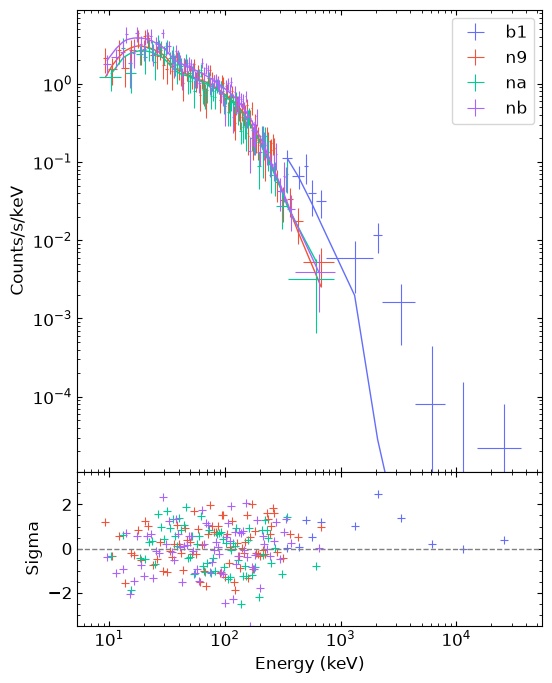

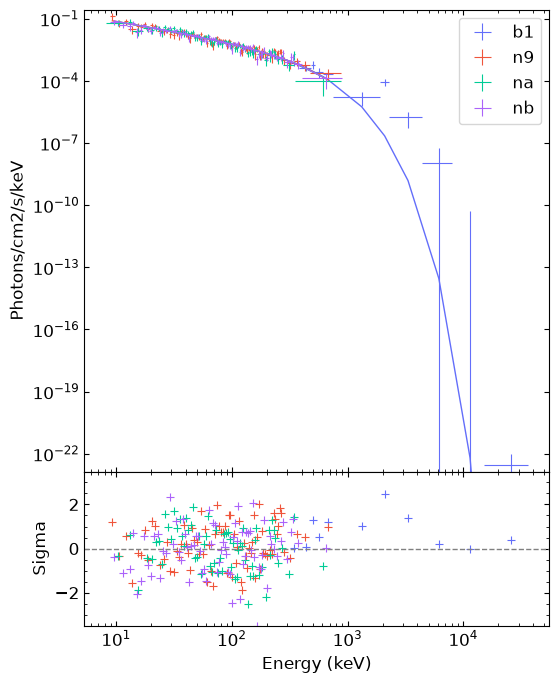

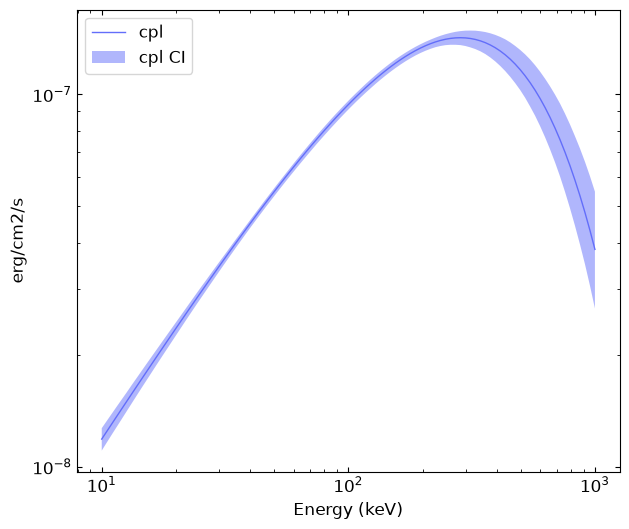

In [4]:

# ---- Stage 3: fit ----
for _, grb in grbs_df.iterrows():
    load_grb(grb)
    fit_tintegrated(model_name='cpl')
 